# **Do Spotify audio features capture a meaningful underlying structure of music, and how does this structure compare to genre labels and popularity?**

*names*

# Intro
...

---

# **Global Pipeline**

## **1. Overall ML Strategy** READ

This project is intentionally designed as a multi-perspective machine learning study rather than a single task. For that reason, we approach the Spotify dataset as a structured environment in which different modeling tasks can reveal different aspects of music.

The central idea is that the same acoustic feature space can support multiple legitimate ML questions, each with a different interpretation. In some cases, we want to predict a label from the audio features, such as genre or popularity. In other cases, we want to remove labels entirely and explore how songs organize themselves naturally. These are not competing approaches. They are complementary views of the same data.

Our project is therefore built around four main analytical arcs:*

Each block addresses a distinct research question. Genre classification tests whether playlist categories correspond to stable acoustic patterns. Popularity modeling asks whether musical success is reflected in sound, while also recognizing that popularity is shaped by many external variables not present in the dataset. Clustering investigates whether the songs contain latent musical archetypes that cut across Spotify’s labels. Dimensionality reduction provides a visual and geometric representation of the acoustic space, helping us interpret the results of the supervised and unsupervised analyses.

At the global level, the project follows a modular pipeline:

The main steps of the machine learning workflow are:

1. **Data Loading and Exploration**  
   We begin by loading the dataset and understanding its structure, variable types, and distributions. This step allows us to identify potential targets, features, and data quality issues.

2. **Data Cleaning and Curation**  
   We clean the dataset by handling duplicates, ensuring consistency, and defining the correct unit of analysis (song-level vs playlist-level). This step ensures that the data is reliable and suitable for modeling.

3. **Data Splitting**  
   The dataset is split into training, validation, and test sets before any transformation that learns from the data. This prevents data leakage and ensures that model evaluation reflects true generalization.

4. **Managing Missing Values**  
   Missing values are identified and handled using appropriate imputation strategies. All imputation parameters are computed on the training data only to avoid leakage.

5. **Encoding Categorical Variables**  
   Categorical variables are transformed into numerical representations where needed, with careful distinction between features and target variables.

6. **Feature Engineering and Selection**  
   A core set of numerical audio features is defined globally, and task-specific feature transformations are introduced later within each modeling block. This allows us to balance consistency with flexibility.

7. **Feature Scaling**  
   Numerical features are scaled to ensure comparability across variables, which is especially important for distance-based models, clustering, and neural networks.

8. **Model Training and Evaluation (Task-Specific)**  
   For each analytical block, we:
- Define the prediction target (if supervised)
- Select appropriate models
- Train models on the training set
- Tune using validation data
- Evaluate performance using suitable metrics

10. **Interpretation and Comparison of Results**  
   We analyze model outputs to understand:
-  Which features are important
- How different models behave
- What the results reveal about the structure of the data

11. **Cross-Block Synthesis and Conclusions**  
    Finally, we integrate findings across all modeling tasks to draw broader conclusions about musical structure, genre, and popularity.

A final reason for this strategy is interpretive strength. If the project only included one target, our conclusions would remain narrow. By combining classification, prediction, clustering, and visualization, we can compare what is easy to learn from the audio features and what is not. That contrast is meaningful. If genre is predictable but popularity is not, that tells us something important about the difference between musical structure and social reception. If clusters cut across genres, that tells us something about the limits of playlist labels as representations of musical reality.

In short, the overall ML strategy of this project is to use one dataset, one coherent preprocessing foundation, and multiple machine learning perspectives to produce a richer and more revealing analysis of music.

## **2. Data Loading & Exploration**

The first operational step in the project is to load the dataset and study its structure carefully before making any modeling decisions. We begin by inspecting the size of the dataset, the column names, and the data types of each variable. This allows us to distinguish between numerical features, categorical labels, identifiers, descriptive metadata, and temporal information. In the Spotify dataset, this distinction is especially important because the file contains a mixture of useful modeling variables and columns that are better treated as metadata only.

At a conceptual level, we separate the columns into several groups:

- **Identifiers**, such as track IDs, playlist IDs, and album IDs
- **Descriptive metadata**, such as track names, artist names, and album names
- **Playlist labels**, such as genre and subgenre
- **Target-like variables**, such as track popularity
- **Core numerical audio features**, such as danceability, energy, acousticness, valence, loudness, tempo, duration, and related descriptors
- **Temporal variables**, such as release date

This grouping is essential because not all variables should be treated as predictive inputs. Identifiers are not meaningful features. Metadata may be useful for interpretation, but not necessarily for numerical modeling. Audio features, by contrast, form the core representation of the songs and will be the main basis of the machine learning tasks.

The exploratory stage also allows us to understand the distribution of the main variables before any transformation is applied. We examine the numerical ranges and distributions of the acoustic features, looking for skewness, concentration, possible outliers, and very low-variance variables. We also inspect the distribution of genre labels, subgenres, and popularity values. This matters because imbalance and uneven distributions can strongly affect both modeling and evaluation.

For example, if some genres are much more common than others, then a naive classifier may achieve an apparently strong overall accuracy while still performing poorly on minority categories. Similarly, if popularity is heavily concentrated in part of its range, then regression or tiered classification may require careful framing to avoid misleading conclusions.

Another important purpose of this section is to form initial hypotheses. Exploratory analysis should not be treated as decoration. It helps us anticipate what later models are likely to struggle with. If two genres appear highly overlapping in the audio space, then confusion between them in a classifier would later make sense. If popularity appears widely spread with little visible separation across features, then weak predictive performance would not necessarily indicate poor modeling, but rather a limit of the available feature space.

This stage is also where we begin to notice dataset-specific risks. In a playlist-based music dataset, songs may appear more than once, either through repeated tracks or through multiple playlist memberships. That affects how we think about the unit of analysis and about leakage. Even at the exploration stage, these observations matter because they influence how we define the cleaned dataset later.

The main objective of this section is therefore not simply to “look at the data,” but to understand what kind of machine learning problem this dataset really supports. The more precise and thoughtful this understanding is, the stronger every downstream decision becomes.

Dataset loaded successfully.
Shape: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
30056,697MjF1454XKvZmTuqkWmD,I Miss You,Jeriqo,45,2vJ6FDg6ZMS56U8Wbiw2Oz,I Miss You,2019-02-05,Pop Hits 2000-2019,6mtYuOxzl58vSGnEDtZ9uB,edm,pop edm,0.520,0.789,0,-7.717,1,0.0432,0.004910,0.000013,0.0816,0.415,174.026,216347
11827,3x2bXiU0o4WbsPkawXlfDA,Who Are You,The Who,17,6LRJF97hgXHj8uMLHyCDbh,Who Are You (Remastered),1978-08-18,House Of The Rising Sun,1bMYfBHYBCRHY5LGkjlpSy,rock,album rock,0.651,0.661,9,-11.405,1,0.0511,0.265000,0.003130,0.1060,0.489,156.371,378707
23571,0jEaPBjFAWjQTMVouRwaHi,Happy,The Beef Seeds,30,4IQn9XpweytNX2cUe2NBUH,Keepin' it Beefy,2015-01-19,Bluegrass Covers,37i9dQZF1DX56crgoe4TG3,r&b,hip pop,0.640,0.758,10,-5.204,1,0.1600,0.665000,0.000000,0.1270,0.932,86.529,218044
14741,5EKUb1FKsyYVaSXb41YBIj,ONE,Rev Theory,35,0gGic19XvEiHKKWBV7M4YM,ONE,2020-01-15,Rock Hard,37i9dQZF1DWWJOmJ7nRx0C,rock,hard rock,0.398,0.966,4,-2.352,0,0.0453,0.000006,0.000000,0.3030,0.520,90.016,208196
25570,300DUx4tdtCdGEUXR032jA,Palace/Curse,The Internet,62,69g3CtOVg98TPOwqmI2K7Q,Ego Death,2015-06-26,NEO-soul,3q3M4VCymcMoxJ3Tl7mRqN,r&b,neo soul,0.447,0.625,10,-8.212,0,0.3230,0.035100,0.000727,0.2430,0.261,67.104,440013



Column names:
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

Data types:


track_id                     object
track_name                   object
track_artist                 object
track_popularity              int64
track_album_id               object
track_album_name             object
track_album_release_date     object
playlist_name                object
playlist_id                  object
playlist_genre               object
playlist_subgenre            object
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

...

,missing_count,missing_percent
track_name,5,0.015229
track_artist,5,0.015229
track_album_name,5,0.015229



Number of fully duplicated rows: 0
Number of duplicated track_id values: 4477

Identifier columns:
['track_id', 'track_album_id', 'playlist_id']

Text / metadata columns:
['track_name', 'track_artist', 'track_album_name', 'playlist_name']

Categorical columns:
['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']

Numerical columns:
['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.0,42.477081,24.984074,0.000000,24.0000,45.000000,62.00000,100.000
danceability,32833.0,0.654850,0.145085,0.000000,0.5630,0.672000,0.76100,0.983
energy,32833.0,0.698619,0.180910,0.000175,0.5810,0.721000,0.84000,1.000
key,32833.0,5.374471,3.611657,0.000000,2.0000,6.000000,9.00000,11.000
loudness,32833.0,-6.719499,2.988436,-46.448000,-8.1710,-6.166000,-4.64500,1.275
mode,32833.0,0.565711,0.495671,0.000000,0.0000,1.000000,1.00000,1.000
speechiness,32833.0,0.107068,0.101314,0.000000,0.0410,0.062500,0.13200,0.918
acousticness,32833.0,0.175334,0.219633,0.000000,0.0151,0.080400,0.25500,0.994
instrumentalness,32833.0,0.084747,0.224230,0.000000,0.0000,0.000016,0.00483,0.994
liveness,32833.0,0.190176,0.154317,0.000000,0.0927,0.127000,0.24800,0.996



Categorical summary:


,count,unique,top,freq
track_id,32833,28356,7BKLCZ1jbUBVqRi2FVlTVw,10
track_name,32828,23449,Poison,22
track_artist,32828,10692,Martin Garrix,161
track_album_id,32833,22545,5L1xcowSxwzFUSJzvyMp48,42
track_album_name,32828,19743,Greatest Hits,139
track_album_release_date,32833,4530,2020-01-10,270
playlist_name,32833,449,Indie Poptimism,308
playlist_id,32833,471,4JkkvMpVl4lSioqQjeAL0q,247
playlist_genre,32833,6,edm,6043
playlist_subgenre,32833,24,progressive electro house,1809


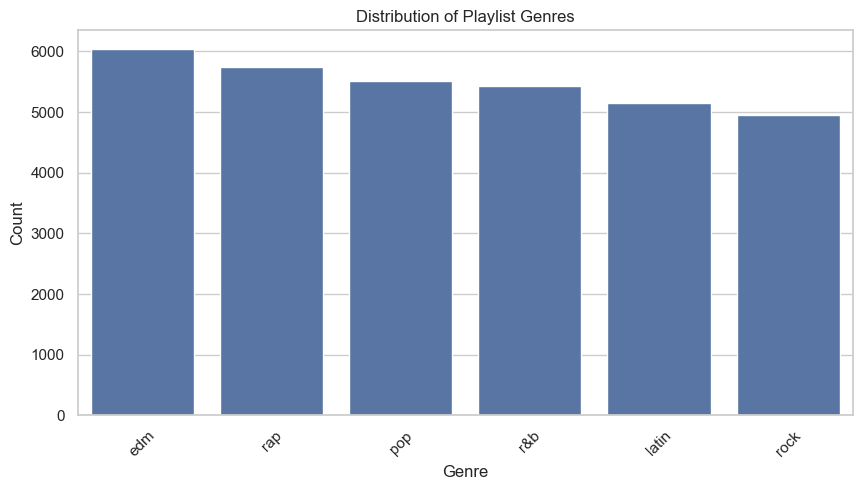

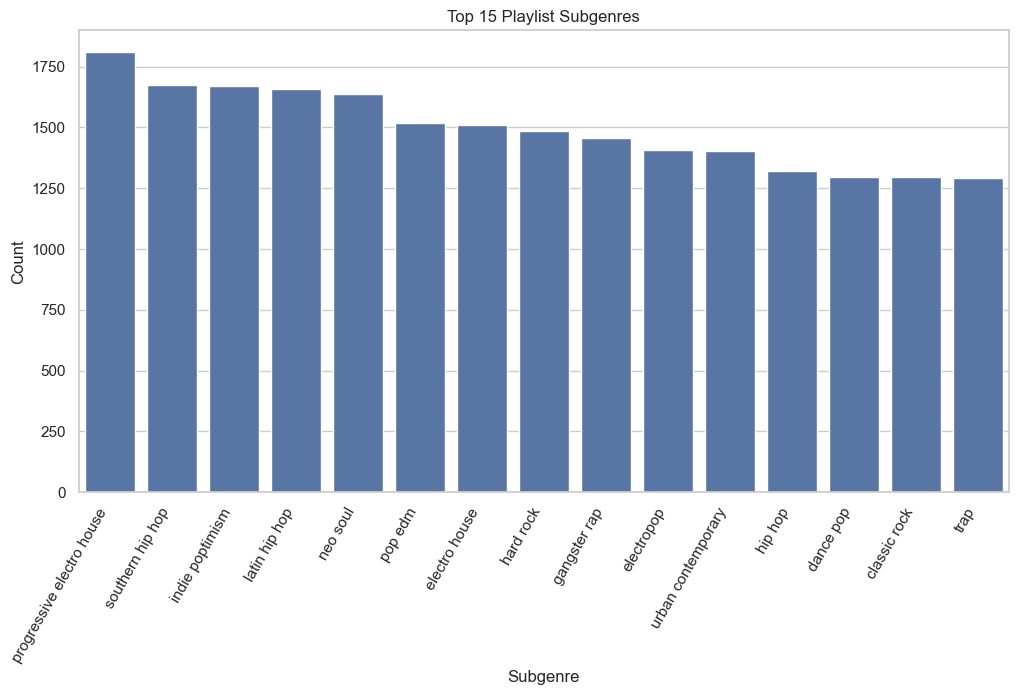

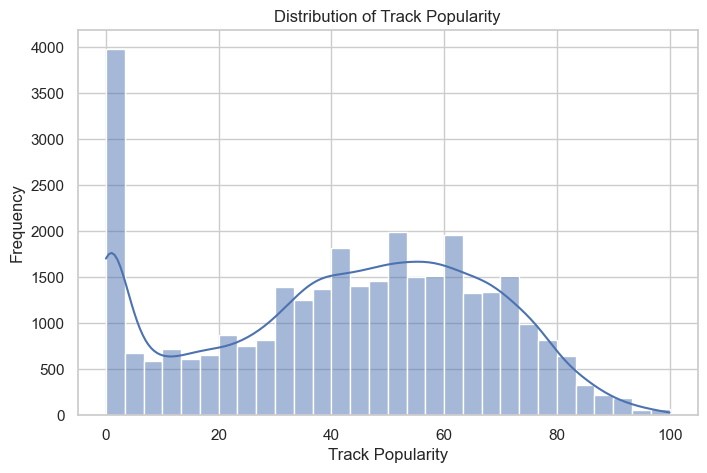

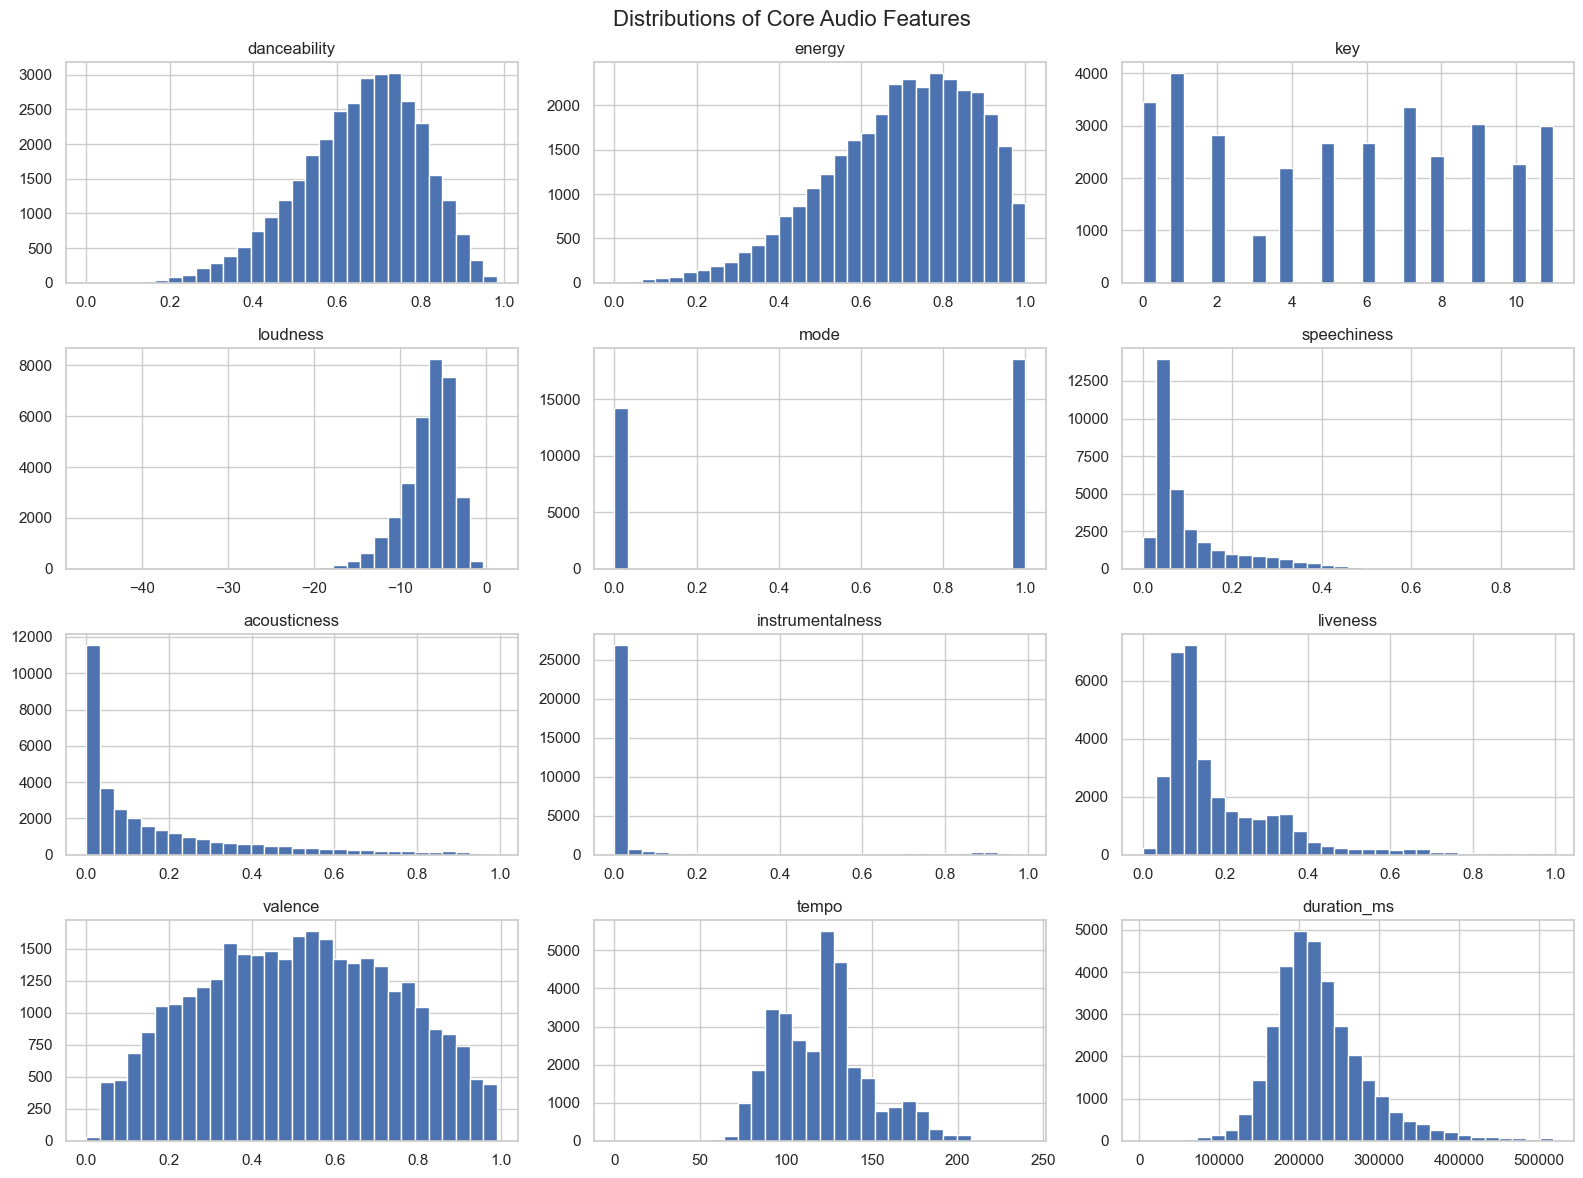

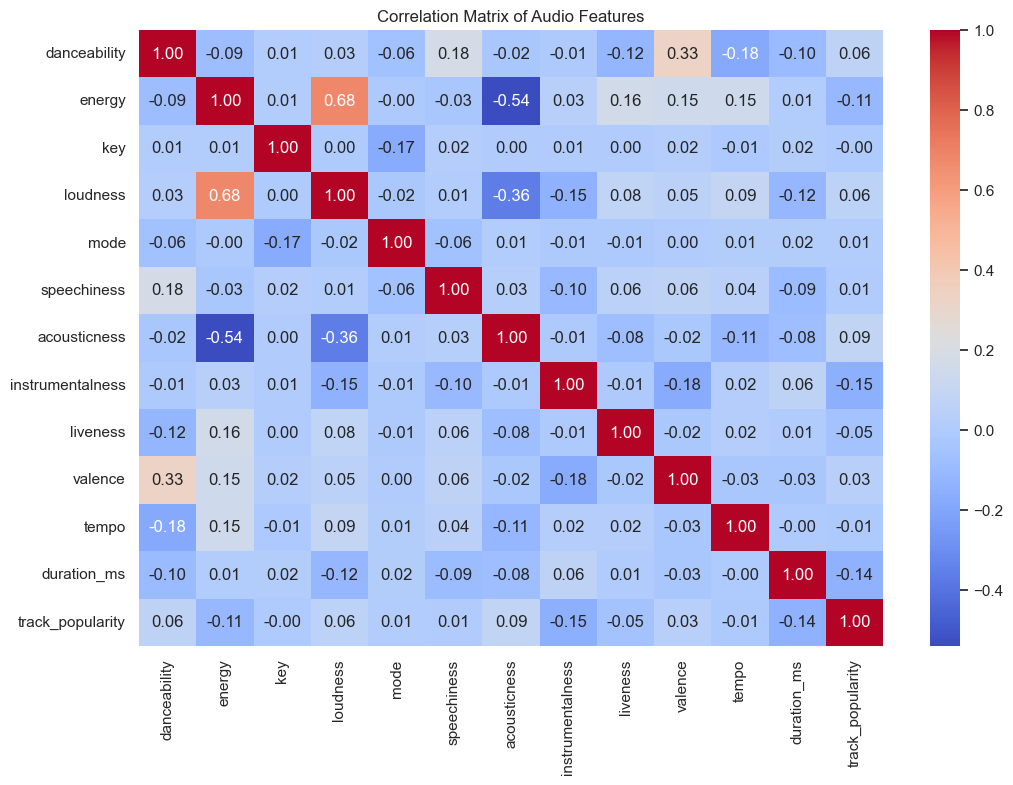

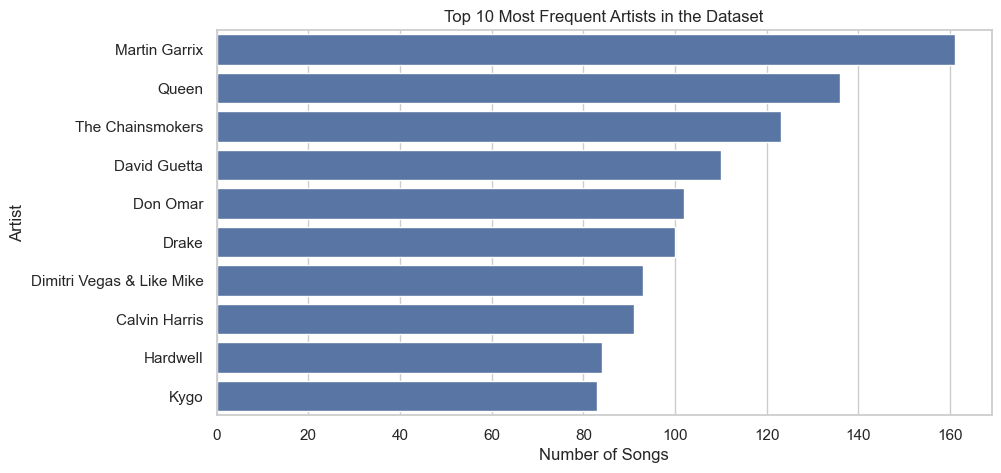


Number of tracks appearing more than once: 3166


track_id
7BKLCZ1jbUBVqRi2FVlTVw    10
3eekarcy7kvN4yt5ZFzltW     9
14sOS5L36385FJ3OL8hew4     9
7LzouaWGFCy4tkXDOOnEyM     8
2b8fOow8UzyDFAE27YhOZM     8
0sf12qNH5qcw8qpgymFOqD     8
0qaWEvPkts34WF68r8Dzx9     8
2Fxmhks0bxGSBdJ92vM42m     8
6oJ6le65B3SEqPwMRNXWjY     8
6Gg1gjgKi2AK4e0qzsR7sd     8
Name: count, dtype: int64


Quick exploration summary:
- Number of rows: 32833
- Number of columns: 23
- Number of numerical columns: 13
- Number of categorical columns: 10
- Fully duplicated rows: 0
- Number of genres: 6
- Number of subgenres: 24
- Unique tracks: 28356

Exploration step completed.


In [5]:
# 2. DATA LOADING & EXPLORATION

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot style
sns.set(style="whitegrid")


# 2.1 Load dataset

df = pd.read_csv("spotify_songs.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")


# 2.2 First look at the data

display(df.head())
display(df.sample(5, random_state = 42))


# 2.3 Basic structure

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nGeneral info:")
df.info()


# 2.4 Missing values

missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

display(missing_summary[missing_summary["missing_count"] > 0])


# 2.5 Duplicate rows

total_duplicates = df.duplicated().sum()
print(f"\nNumber of fully duplicated rows: {total_duplicates}")

# Optional: duplicates by track_id
if "track_id" in df.columns:
    duplicate_tracks = df["track_id"].duplicated().sum()
    print(f"Number of duplicated track_id values: {duplicate_tracks}")

# 2.6 Separate columns conceptually

identifier_cols = [
    col for col in ["track_id", "track_album_id", "playlist_id"] if col in df.columns
]

text_metadata_cols = [
    col for col in ["track_name", "track_artist", "track_album_name", "playlist_name"] if col in df.columns
]

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nIdentifier columns:")
print(identifier_cols)

print("\nText / metadata columns:")
print(text_metadata_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)


# 2.7 Descriptive statistics

print("\nNumerical summary:")
display(df[numerical_cols].describe().T)

print("\nCategorical summary:")
display(df[categorical_cols].describe().T)


# 2.8 Class distribution for genre / subgenre

if "playlist_genre" in df.columns:
    plt.figure(figsize=(10, 5))
    genre_counts = df["playlist_genre"].value_counts()
    sns.barplot(x=genre_counts.index, y=genre_counts.values)
    plt.title("Distribution of Playlist Genres")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

if "playlist_subgenre" in df.columns:
    plt.figure(figsize=(12, 6))
    subgenre_counts = df["playlist_subgenre"].value_counts().head(15)
    sns.barplot(x=subgenre_counts.index, y=subgenre_counts.values)
    plt.title("Top 15 Playlist Subgenres")
    plt.xlabel("Subgenre")
    plt.ylabel("Count")
    plt.xticks(rotation=60, ha="right")
    plt.show()


# 2.9 Popularity distribution

if "track_popularity" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df["track_popularity"], bins=30, kde=True)
    plt.title("Distribution of Track Popularity")
    plt.xlabel("Track Popularity")
    plt.ylabel("Frequency")
    plt.show()


# 2.10 Distribution of core audio features

audio_features = [
    "danceability", "energy", "key", "loudness", "mode", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms"
]

audio_features = [col for col in audio_features if col in df.columns]

df[audio_features].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distributions of Core Audio Features", fontsize=16)
plt.tight_layout()
plt.show()


# 2.11 Correlation heatmap for numerical/audio features

plt.figure(figsize=(12, 8))
corr_matrix = df[audio_features + (["track_popularity"] if "track_popularity" in df.columns else [])].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Audio Features")
plt.show()


# 2.12 Songs per artist / repeated track inspection

if "track_artist" in df.columns:
    top_artists = df["track_artist"].value_counts().head(10)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_artists.values, y=top_artists.index)
    plt.title("Top 10 Most Frequent Artists in the Dataset")
    plt.xlabel("Number of Songs")
    plt.ylabel("Artist")
    plt.show()

if "track_id" in df.columns:
    repeated_track_counts = df["track_id"].value_counts()
    repeated_tracks = repeated_track_counts[repeated_track_counts > 1]
    print(f"\nNumber of tracks appearing more than once: {repeated_tracks.shape[0]}")
    display(repeated_tracks.head(10))


# 2.13 Quick observations helper
# ------------------------------------------------------------
print("\nQuick exploration summary:")
print(f"- Number of rows: {df.shape[0]}")
print(f"- Number of columns: {df.shape[1]}")
print(f"- Number of numerical columns: {len(numerical_cols)}")
print(f"- Number of categorical columns: {len(categorical_cols)}")
print(f"- Fully duplicated rows: {total_duplicates}")

if "playlist_genre" in df.columns:
    print(f"- Number of genres: {df['playlist_genre'].nunique()}")

if "playlist_subgenre" in df.columns:
    print(f"- Number of subgenres: {df['playlist_subgenre'].nunique()}")

if "track_id" in df.columns:
    print(f"- Unique tracks: {df['track_id'].nunique()}")

# ------------------------------------------------------------
# 2.14 Optional: save exploration summary tables
# ------------------------------------------------------------
missing_summary.to_csv("missing_summary.csv", index=True)

if "playlist_genre" in df.columns:
    genre_counts.to_csv("genre_counts.csv", header=["count"])

if "playlist_subgenre" in df.columns:
    df["playlist_subgenre"].value_counts().to_csv("subgenre_counts.csv", header=["count"])

print("\nExploration step completed.")

## **3. Data Cleaning**

Once the structure of the dataset is understood, the next step is to clean and curate it in a way that makes the later analysis both valid and interpretable. Data cleaning is often described as a technical preprocessing step, but in practice it is also a conceptual step. Cleaning the data means deciding what the actual observational unit is, which rows are trustworthy, which columns are useful, and how to avoid creating misleading performance estimates.

The first issue we address is duplication. In a Spotify playlist dataset, the same song may appear more than once, especially if it is included in multiple playlists. This is not automatically an error, but it does create an important methodological challenge. If the same or nearly identical song representation appears in both training and evaluation data, then the model may appear to generalize well when in reality it is only recognizing repeated content. That would inflate our results and weaken the credibility of the project.

For this reason, we examine duplicate rows and repeated track identifiers carefully. Where appropriate, we construct a song-level representation in which each track is represented only once for tasks that are truly about the acoustic identity of the song. This is especially relevant for genre classification and popularity modeling, where we want the model to learn patterns of music rather than patterns of repeated playlist membership.

Another cleaning step involves the consistency of variable formats. Temporal variables such as release dates need to be parsed properly before they can be used or summarized. This is not just a formatting concern. If release information is relevant for interpretation or for later engineered features such as release year, then the variable must be converted into a consistent and reliable format.

We also inspect categorical fields for potential inconsistencies, rare labels, or formatting irregularities. Genre and subgenre labels are useful targets, but because they come from playlist organization rather than laboratory-style annotation, we should not assume they are perfect. A cleaning step here helps ensure that labels are comparable and that any obvious inconsistencies are addressed before supervised modeling begins.

An important conceptual point in this section is that cleaning does not mean stripping the data aggressively until only the easiest subset remains. A weak project often cleans away complexity. A stronger project recognizes complexity and handles it explicitly. If repeated songs, noisy playlist labels, or metadata irregularities are present, the goal is not to hide them, but to decide how they should be managed in a principled way.

This section is also where we clarify the distinction between data used for modeling and data retained for interpretation. Track names, artist names, and playlist names may not be used as input features in the main models, but they remain valuable for inspecting examples, interpreting clusters, or explaining interesting cases later in the notebook. Cleaning therefore includes deciding what is excluded from modeling and what is retained for context.

By the end of this stage, the goal is to have a curated dataset that is structurally reliable, conceptually coherent, and suitable for task-specific analysis. This is one of the most important foundations of the whole notebook, because later results are only as trustworthy as the data preparation that produced them.

In [7]:
# 3. DATA CLEANING

# Make a working copy
df_clean = df.copy()

print("Initial shape:", df_clean.shape)


# 3.1 Check and remove fully duplicated rows

full_duplicates = df_clean.duplicated().sum()
print(f"Number of fully duplicated rows: {full_duplicates}")

if full_duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print("Shape after removing fully duplicated rows:", df_clean.shape)
else:
    print("No fully duplicated rows were removed.")


# 3.2 Check duplicated track_id values

track_duplicates = df_clean["track_id"].duplicated().sum()
print(f"Number of duplicated track_id values: {track_duplicates}")

# Keep only one row per unique track_id
# This converts the dataset to song-level representation
df_clean = df_clean.drop_duplicates(subset="track_id")
print("Shape after keeping one row per unique track_id:", df_clean.shape)


# 3.3 Convert release date to datetime and extract year

df_clean["track_album_release_date"] = pd.to_datetime(
    df_clean["track_album_release_date"],
    errors="coerce"
)

df_clean["release_year"] = df_clean["track_album_release_date"].dt.year


# 3.4 Drop text metadata columns from modeling dataset
# Keep them out of ML features, but preserve structured variables

metadata_to_drop = [
    "track_name",
    "track_artist",
    "track_album_name",
    "playlist_name"
]

df_model = df_clean.drop(columns=metadata_to_drop)

print("\nDropped metadata columns:")
print(metadata_to_drop)


# 3.5 Final sanity checks

print("\nFinal cleaned dataset shape:", df_model.shape)
print("Remaining fully duplicated rows:", df_model.duplicated().sum())
print("Unique track_id values:", df_model["track_id"].nunique())

# Optional: preview cleaned dataset
display(df_model.head())

Initial shape: (32833, 23)
Number of fully duplicated rows: 0
No fully duplicated rows were removed.
Number of duplicated track_id values: 4477
Shape after keeping one row per unique track_id: (28356, 23)

Dropped metadata columns:
['track_name', 'track_artist', 'track_album_name', 'playlist_name']

Final cleaned dataset shape: (28356, 20)
Remaining fully duplicated rows: 0
Unique track_id values: 28356


,track_id,track_popularity,track_album_id,track_album_release_date,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year
0,6f807x0ima9a1j3VPbc7VN,66,2oCs0DGTsRO98Gh5ZSl2Cx,2019-06-14,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,2019.0
1,0r7CVbZTWZgbTCYdfa2P31,67,63rPSO264uRjW1X5E6cWv6,2019-12-13,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,2019.0
2,1z1Hg7Vb0AhHDiEmnDE79l,70,1HoSmj2eLcsrR0vE9gThr4,2019-07-05,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2019.0
3,75FpbthrwQmzHlBJLuGdC7,60,1nqYsOef1yKKuGOVchbsk6,2019-07-19,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,2019.0
4,1e8PAfcKUYoKkxPhrHqw4x,69,7m7vv9wlQ4i0LFuJiE2zsQ,2019-03-05,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,2019.0


## **4. Data Splitting**

Data splitting is one of the most important methodological steps in the project because it determines whether model performance is measured fairly and realistically. The purpose of this step is to create separate subsets of the data for training, validation, and testing, so that model performance can be evaluated on observations that were not used during learning.

This is especially important in our dataset because, as observed during the exploration stage, many songs appear multiple times across playlists. If repeated tracks were allowed to remain across different subsets, the same song could appear in both the training and test sets. In that case, a model might appear to generalize well simply because it had already seen that song before, rather than because it learned a pattern that applies to unseen music. This would lead to data leakage and artificially inflated performance.

To avoid this problem, we first converted the dataset into a song-level representation by keeping only one row per unique `track_id`. Once this is done, we can split the dataset more reliably.

At the global level, we create:

- a **training set**, used to fit models
- a **validation set**, used for tuning and model selection
- a **test set**, reserved for final evaluation

This separation allows us to compare models rigorously while keeping the final test set untouched until the end of each analytical block.

Because the project includes both classification and unsupervised tasks, the exact use of the split will vary slightly across blocks. For supervised tasks such as genre classification and popularity modeling, the split is essential for valid evaluation. For unsupervised tasks such as clustering and dimensionality reduction, the split is less central in the same way, but the cleaned and prepared dataset still serves as the common foundation.

The key principle is that all later preprocessing steps that learn from the data, such as imputation, scaling, and some forms of feature selection, must be fitted only on the training set and then applied consistently to validation and test data. This preserves the integrity of the machine learning pipeline and ensures that our results reflect true generalization rather than accidental information leakage.

In [9]:
# ============================================================
# 4. DATA SPLITTING
# ============================================================

from sklearn.model_selection import train_test_split

# Make a copy for safety
df_split = df_model.copy()

print("Dataset shape before splitting:", df_split.shape)

# ------------------------------------------------------------
# 4.1 Train / Test split
# ------------------------------------------------------------
# First split: 80% train+val, 20% test
train_val_df, test_df = train_test_split(
    df_split,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# ------------------------------------------------------------
# 4.2 Train / Validation split
# ------------------------------------------------------------
# Second split: from the remaining 80%, create 60% train and 20% validation overall
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,   # 25% of 80% = 20% of total
    random_state=42,
    shuffle=True
)

# ------------------------------------------------------------
# 4.3 Check shapes
# ------------------------------------------------------------
print("Training set shape:  ", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:      ", test_df.shape)

# ------------------------------------------------------------
# 4.4 Check proportions
# ------------------------------------------------------------
total_rows = len(df_split)

print("\nProportions:")
print(f"Train:      {len(train_df) / total_rows:.2%}")
print(f"Validation: {len(val_df) / total_rows:.2%}")
print(f"Test:       {len(test_df) / total_rows:.2%}")

# ------------------------------------------------------------
# 4.5 Optional sanity checks
# ------------------------------------------------------------
# Make sure there is no overlap between track_ids
train_ids = set(train_df["track_id"])
val_ids = set(val_df["track_id"])
test_ids = set(test_df["track_id"])

print("\nOverlap checks:")
print("Train ∩ Validation:", len(train_ids.intersection(val_ids)))
print("Train ∩ Test:      ", len(train_ids.intersection(test_ids)))
print("Validation ∩ Test: ", len(val_ids.intersection(test_ids)))

# ------------------------------------------------------------
# 4.6 Reset indices for cleanliness
# ------------------------------------------------------------
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nFinal split completed successfully.")

Dataset shape before splitting: (28356, 20)
Training set shape:   (17013, 20)
Validation set shape: (5671, 20)
Test set shape:       (5672, 20)

Proportions:
Train:      60.00%
Validation: 20.00%
Test:       20.00%

Overlap checks:
Train ∩ Validation: 0
Train ∩ Test:       0
Validation ∩ Test:  0

Final split completed successfully.


## **5. Managing Missing Values**

Handling missing values is an essential step in any machine learning pipeline, as incomplete data can negatively affect both model performance and interpretation. However, the appropriate strategy depends on the extent and nature of the missingness.

From the exploratory analysis, we observed that missing values are extremely limited in this dataset. Specifically, only a very small number of entries are missing in the columns `track_name`, `track_artist`, and `track_album_name`. These columns are primarily descriptive metadata and are not part of the core numerical feature space used for modeling.

Importantly, none of the core numerical audio features contain missing values. This is a strong advantage, as it allows us to avoid potentially complex imputation strategies for the main predictors. Since the audio features form the basis of all modeling tasks in the project, their completeness ensures that the feature space remains reliable and consistent.

Given these observations, we adopt a minimal and principled approach:

- Missing values in metadata columns are not critical for modeling and can be safely handled without affecting predictive performance.
- Since these columns are not used as model inputs, we do not need to apply numerical imputation strategies.
- The dataset is therefore effectively complete with respect to the variables that matter for machine learning.

This decision reflects an important principle: not all missing values require intervention. Over-processing a dataset when missingness is negligible can introduce unnecessary complexity without improving results.

By confirming that the modeling feature space is complete, we ensure that subsequent steps such as scaling, feature engineering, and model training can proceed without distortion from imputed values.

In [11]:
# ============================================================
# 5. MANAGING MISSING VALUES
# ============================================================

# Check missing values again on cleaned dataset
missing_counts = df_model.isnull().sum()
missing_percent = (df_model.isnull().mean() * 100)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0])

# ------------------------------------------------------------
# 5.1 Handle missing values (minimal approach)
# ------------------------------------------------------------

# Since missing values are only in metadata columns and very few,
# we simply drop rows with missing metadata (safe decision)

df_model = df_model.dropna()

print("\nShape after removing rows with missing values:", df_model.shape)

# ------------------------------------------------------------
# 5.2 Final check
# ------------------------------------------------------------
print("\nRemaining missing values:")
print(df_model.isnull().sum().sum())

,missing_count,missing_percent
track_album_release_date,1681,5.928199
release_year,1681,5.928199



Shape after removing rows with missing values: (26675, 20)

Remaining missing values:
0


## **6. Encoding**

Machine learning models require numerical inputs, which means that categorical variables must be converted into a numerical representation before being used in modeling. However, not all categorical variables in the dataset should be treated as model features, and encoding must be applied carefully depending on the role of each variable.

In this dataset, we distinguish between three types of categorical variables:

- **Metadata columns** (e.g., track name, artist name, playlist name), which are descriptive and not used for modeling
- **Identifier columns** (e.g., track_id, playlist_id), which uniquely identify observations but do not contain predictive information
- **Target variables** (e.g., playlist_genre, playlist_subgenre), which are used as labels in supervised learning tasks

Since our modeling approach is primarily based on numerical audio features, most categorical variables are not included as input features. This is a deliberate choice. Including high-cardinality categorical variables such as artist or track name could introduce noise, increase dimensionality unnecessarily, and shift the focus away from the acoustic properties that define the project.

For supervised tasks, such as genre classification, the target variable must be encoded into a numerical format. This allows machine learning models to learn the mapping between input features and output classes.

We therefore apply encoding selectively:

- Target variables are encoded when required for classification tasks
- Feature encoding is avoided for metadata and identifier columns
- The core feature space remains focused on numerical audio descriptors

This approach ensures that the model learns from meaningful, interpretable inputs and avoids overcomplicating the feature space with unnecessary transformations.

Encoding decisions are therefore not purely technical, but conceptual: they reflect what information we want the model to use and what we want to exclude from learning.

In [13]:
# ============================================================
# 6. ENCODING
# ============================================================

# Make a copy
df_encoded = df_model.copy()

# ------------------------------------------------------------
# 6.1 Identify categorical columns
# ------------------------------------------------------------
categorical_cols = df_encoded.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:")
print(categorical_cols)

# ------------------------------------------------------------
# 6.2 Remove identifier columns from categorical list
# (we don't encode IDs)
# ------------------------------------------------------------
identifier_cols = ["track_id", "track_album_id", "playlist_id"]

categorical_cols = [col for col in categorical_cols if col not in identifier_cols]

print("\nCategorical columns after removing identifiers:")
print(categorical_cols)

# ------------------------------------------------------------
# 6.3 Separate target variables (to encode later per task)
# ------------------------------------------------------------
target_cols = ["playlist_genre", "playlist_subgenre"]

print("\nTarget columns (will be encoded later in blocks):")
print(target_cols)

# ------------------------------------------------------------
# 6.4 Final dataset for modeling (no encoding yet)
# ------------------------------------------------------------
print("\nDataset ready for modeling (no encoding applied globally):")
print(df_encoded.shape)

Categorical columns:
['track_id', 'track_album_id', 'playlist_id', 'playlist_genre', 'playlist_subgenre']

Categorical columns after removing identifiers:
['playlist_genre', 'playlist_subgenre']

Target columns (will be encoded later in blocks):
['playlist_genre', 'playlist_subgenre']

Dataset ready for modeling (no encoding applied globally):
(26675, 20)


## **7. Feature Engineering & Selection**

Feature engineering and feature selection are central to this project because they define how songs are represented in the machine learning models. A model can only learn patterns that are present in the feature space, so the quality and structure of the features directly determine the quality of the results.

In this project, we adopt a two-level approach to feature design:

### Global Feature Foundation

At the global level, we define a consistent and reliable set of core features that can be used across all analytical blocks. These features are derived from Spotify’s audio descriptors and include variables such as danceability, energy, loudness, acousticness, valence, tempo, and others.

These variables are well-suited for modeling because:
- they are numerical and standardized
- they directly describe measurable properties of the music
- they are available for all observations (no missing values)

We deliberately exclude:
- **identifier columns** (e.g., track_id), which do not contain predictive information
- **text metadata** (e.g., track name, artist), which are not part of the acoustic signal
- **high-cardinality categorical variables**, which would introduce unnecessary complexity

This ensures that the global feature space remains clean, interpretable, and aligned with the objective of analyzing musical characteristics.

### Task-Specific Feature Engineering

While the global feature set provides a stable foundation, different machine learning tasks may benefit from different feature representations. For this reason, more advanced feature engineering is introduced within each analytical block.

For example:
- In classification tasks, interaction features may help separate genres more clearly
- In popularity modeling, features capturing combinations of energy and valence may reflect different types of musical appeal
- In clustering and dimensionality reduction, we prefer a more neutral feature space to avoid imposing structure artificially

This separation allows us to balance consistency across the project with flexibility for each task.

### Feature Selection

Feature selection is used to ensure that the model focuses on informative variables while avoiding unnecessary noise or redundancy.

At this stage, we:
- retain all core audio features as the baseline feature space
- avoid aggressive feature removal unless clearly justified
- consider correlations between variables, but do not automatically remove correlated features, as their usefulness depends on the model type

This reflects an important principle: feature selection is not only about reducing dimensionality, but about preserving meaningful structure in the data.

Overall, this section establishes a feature space that is:
- clean and consistent
- interpretable
- suitable for multiple machine learning tasks
- flexible enough to support task-specific extensions

This foundation will be reused and refined in the modeling blocks that follow.

Core audio features:
['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

Final feature set shape: (26675, 15)


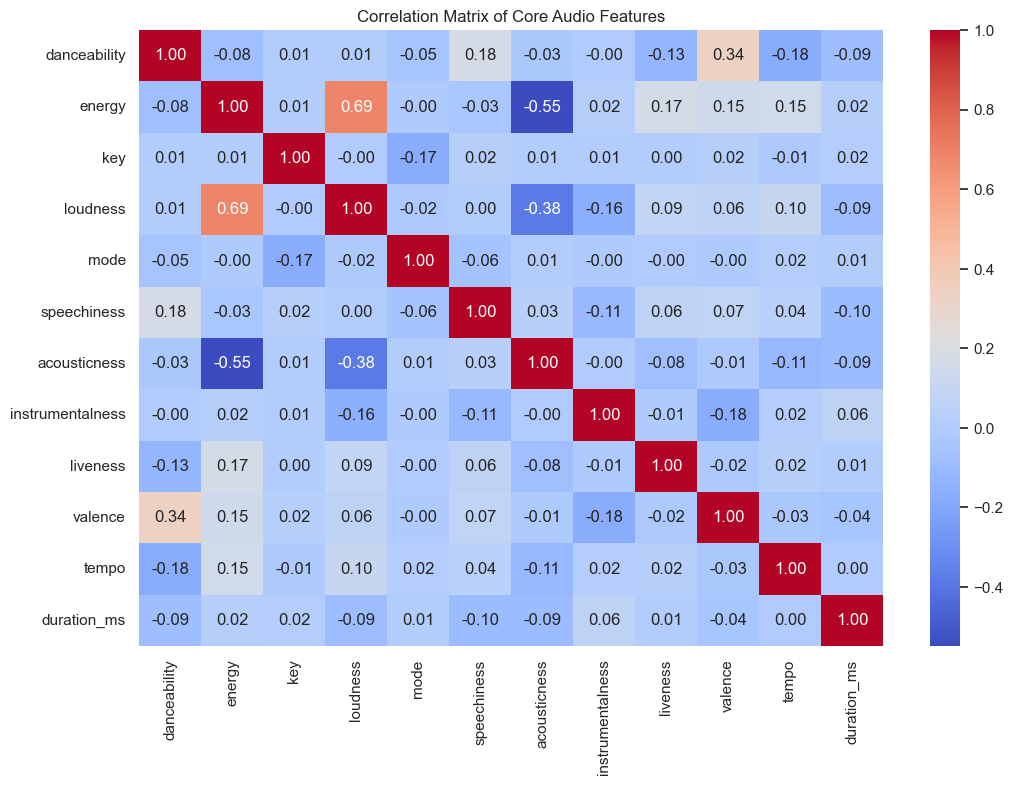


Highly correlated feature pairs (> 0.85):
None


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,track_popularity
0,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,pop,dance pop,66
1,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,pop,dance pop,67
2,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,pop,dance pop,70
3,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,pop,dance pop,60
4,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,pop,dance pop,69


In [15]:
# ============================================================
# 7. FEATURE ENGINEERING & SELECTION
# ============================================================

# Copy dataset
df_features = df_encoded.copy()

# ------------------------------------------------------------
# 7.1 Define core audio features
# ------------------------------------------------------------
core_audio_features = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

# Keep only existing columns (safety check)
core_audio_features = [col for col in core_audio_features if col in df_features.columns]

print("Core audio features:")
print(core_audio_features)

# ------------------------------------------------------------
# 7.2 Keep only relevant columns for modeling
# (features + targets)
# ------------------------------------------------------------
target_columns = ["playlist_genre", "playlist_subgenre", "track_popularity"]

target_columns = [col for col in target_columns if col in df_features.columns]

df_features = df_features[core_audio_features + target_columns]

print("\nFinal feature set shape:", df_features.shape)

# ------------------------------------------------------------
# 7.3 Check correlation between features
# ------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
corr_matrix = df_features[core_audio_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Core Audio Features")
plt.show()

# ------------------------------------------------------------
# 7.4 Optional: identify highly correlated features
# ------------------------------------------------------------
corr_threshold = 0.85

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > corr_threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2))

print("\nHighly correlated feature pairs (> 0.85):")
print(high_corr_pairs if high_corr_pairs else "None")

# ------------------------------------------------------------
# 7.5 Final dataset ready
# ------------------------------------------------------------
display(df_features.head())

## **8. Feature Scaling**

Feature scaling is an essential preprocessing step that ensures all numerical variables are on a comparable scale before being used in machine learning models. In this dataset, the acoustic features have different units and ranges. For example, variables such as danceability and valence are bounded between 0 and 1, while tempo and loudness operate on entirely different numerical scales.

If these raw values are used directly, certain features may dominate the learning process simply because of their magnitude rather than their importance. This is particularly problematic for models that rely on distance or optimization, such as K-Nearest Neighbors, Support Vector Machines, neural networks, clustering algorithms, and dimensionality reduction techniques like PCA.

To address this, we apply feature scaling to standardize the numerical variables. This ensures that each feature contributes proportionally to the model and prevents any single variable from disproportionately influencing the results.

In this project, we use **standardization (z-score scaling)**, which transforms each feature to have:
- a mean of 0
- a standard deviation of 1

An important methodological principle is that scaling parameters must be learned from the training data only and then applied to validation and test sets. This prevents data leakage and ensures that evaluation results reflect true generalization.

At the global level, we define the scaling strategy but do not finalize its application until the modeling stage, where it will be incorporated into pipelines. This allows us to maintain flexibility, since some models (such as tree-based methods) are less sensitive to scaling, while others (such as neural networks and clustering algorithms) require it.

By standardizing the feature space, we ensure that all subsequent modeling steps operate on a stable and comparable representation of the data.

In [17]:
# ============================================================
# 8. FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

# Copy dataset
df_scaled = df_features.copy()

# ------------------------------------------------------------
# 8.1 Define feature matrix (exclude targets)
# ------------------------------------------------------------
feature_columns = [
    col for col in df_scaled.columns
    if col not in ["playlist_genre", "playlist_subgenre", "track_popularity"]
]

X = df_scaled[feature_columns]

print("Feature columns used for scaling:")
print(feature_columns)

# ------------------------------------------------------------
# 8.2 Initialize scaler (do NOT fit yet globally)
# ------------------------------------------------------------
scaler = StandardScaler()

# ------------------------------------------------------------
# 8.3 Example: fit ONLY on training data (important)
# ------------------------------------------------------------
# This is just a placeholder to show the correct logic
# Actual scaling will happen inside each modeling block

# Example usage (DO NOT RUN NOW unless train_df exists):
# scaler.fit(train_df[feature_columns])
# X_train_scaled = scaler.transform(train_df[feature_columns])
# X_val_scaled   = scaler.transform(val_df[feature_columns])
# X_test_scaled  = scaler.transform(test_df[feature_columns])

print("\nScaler defined. Will be applied inside each modeling block.")

Feature columns used for scaling:
['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

Scaler defined. Will be applied inside each modeling block.
